    Исследовательский анализ данных (EDA)

Проект: "Разработка прототипа ИИ-ассистента для прогнозирования академической задолженности студентов"

    Цель исследования

Целью данного исследования является изучение структуры исторических данных об успеваемости студентов, оценка качества данных, выявление закономерностей возникновения академических задолженностей и подготовка рекомендаций для этапа Feature Engineering и последующего обучения моделей машинного обучения.

В ходе исследования решаются следующие задачи:

- изучение структуры датасета;
- анализ качества данных;
- исследование распределения оценок;
- выявление дисциплин и направлений подготовки с повышенным риском возникновения задолженностей;
- анализ сезонности;
- подготовка рекомендаций для построения модели прогнозирования.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. Загрузка данных

In [2]:
df = pd.read_excel("../data/data.xlsx")

print(df.shape)

df.head()

(376007, 10)


,hash,Номер ЛД,Уровень подготовки,Учебная группа,Специальность/направление,Учебный год,Полугодие,Дисциплина,Оценка (без пересдач),Оценка (успеваемость)
0,67a80fffd8d0294a596eda117d7e393c,2010218,Академический бакалавр,БИВТ-20-4,Информатика и вычислительная техника,2020 - 2021,I полугодие,Инженерная компьютерная графика,Хорошо,Хорошо
1,67a80fffd8d0294a596eda117d7e393c,2010218,Академический бакалавр,БИВТ-20-4,Информатика и вычислительная техника,2020 - 2021,I полугодие,Иностранный язык,Удовлетворительно,Удовлетворительно
2,67a80fffd8d0294a596eda117d7e393c,2010218,Академический бакалавр,БИВТ-20-4,Информатика и вычислительная техника,2020 - 2021,I полугодие,История,зачтено,зачтено
3,67a80fffd8d0294a596eda117d7e393c,2010218,Академический бакалавр,БИВТ-20-4,Информатика и вычислительная техника,2020 - 2021,I полугодие,Математика,Хорошо,Хорошо
4,67a80fffd8d0294a596eda117d7e393c,2010218,Академический бакалавр,БИВТ-20-4,Информатика и вычислительная техника,2020 - 2021,I полугодие,Программирование и алгоритмизация,Хорошо,Хорошо


2. Первичный анализ структуры данных

Рассматривается структура датасета, типы данных, количество записей, количество признаков и основные характеристики набора данных.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376007 entries, 0 to 376006
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   hash                       376007 non-null  object
 1   Номер ЛД                   376007 non-null  int64 
 2   Уровень подготовки         376007 non-null  object
 3   Учебная группа             376007 non-null  object
 4   Специальность/направление  376007 non-null  object
 5   Учебный год                376007 non-null  object
 6   Полугодие                  376007 non-null  object
 7   Дисциплина                 376007 non-null  object
 8   Оценка (без пересдач)      189004 non-null  object
 9   Оценка (успеваемость)      196522 non-null  object
dtypes: int64(1), object(9)
memory usage: 28.7+ MB


In [4]:
df.describe(include="all")

,hash,Номер ЛД,Уровень подготовки,Учебная группа,Специальность/направление,Учебный год,Полугодие,Дисциплина,Оценка (без пересдач),Оценка (успеваемость)
count,376007,3.760070e+05,376007,376007,376007,376007,376007,376007,189004,196522
unique,9085,NaN,4,489,27,11,2,2096,9,9
top,002ed2297ad196e3b8a7e668f32d125b,NaN,Академический бакалавр,БЛГ-20-8,Лингвистика,2023 - 2024,II полугодие,Иностранный язык,Отлично,Отлично
freq,218,NaN,203074,3167,75400,158114,195820,30031,54506,57863
mean,NaN,2.084225e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,1.953196e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,7.027200e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.006156e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2.104636e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2.205840e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Датасет содержит информацию об успеваемости студентов по различным дисциплинам за несколько учебных лет. Каждая строка соответствует результату освоения одной дисциплины конкретным студентом. Полученные сведения позволяют перейти к анализу качества данных.

In [5]:
df.columns

Index(['hash', 'Номер ЛД', 'Уровень подготовки', 'Учебная группа',
       'Специальность/направление', 'Учебный год', 'Полугодие', 'Дисциплина',
       'Оценка (без пересдач)', 'Оценка (успеваемость)'],
      dtype='object')

3. Размер датасета

In [6]:
print("Строк:", len(df))
print("Столбцов:", len(df.columns))

print("Уникальных студентов:", df["hash"].nunique())

print("Групп:", df["Учебная группа"].nunique())

print("Направлений:", df["Специальность/направление"].nunique())

print("Дисциплин:", df["Дисциплина"].nunique())

Строк: 376007
Столбцов: 10
Уникальных студентов: 9085
Групп: 489
Направлений: 27
Дисциплин: 2096


Датасет содержит историю успеваемости студентов.
Каждая строка соответствует одному результату по дисциплине.

4. Пропуски

In [7]:
missing = pd.DataFrame({
    "Количество": df.isna().sum(),
    "Процент": round(df.isna().mean()*100,2)
})

missing.sort_values("Процент", ascending=False)

,Количество,Процент
Оценка (без пересдач),187003,49.73
Оценка (успеваемость),179485,47.73
hash,0,0.00
Номер ЛД,0,0.00
Уровень подготовки,0,0.00
Учебная группа,0,0.00
Специальность/направление,0,0.00
Учебный год,0,0.00
Полугодие,0,0.00
Дисциплина,0,0.00


График "Пропуски в данных"

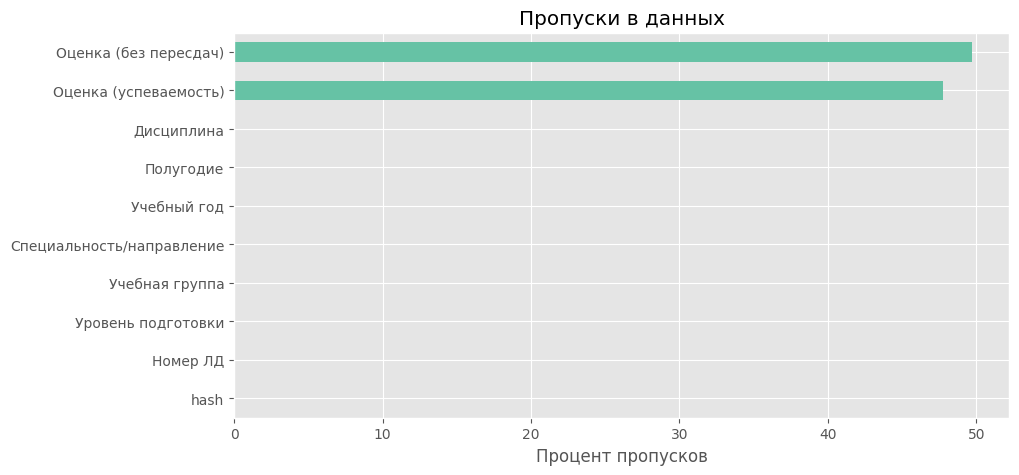

In [8]:
plt.figure(figsize=(10,5))

missing["Процент"].sort_values().plot.barh()

plt.xlabel("Процент пропусков")
plt.title("Пропуски в данных")

plt.show()

Наибольшее количество пропусков находится в столбцах с оценками.

Вероятнее всего это связано с различными формами контроля
(экзамен/зачет), а не с потерей данных.

5. Проверка дубликатов

In [9]:
duplicates = df.duplicated().sum()

print("Количество дубликатов:", duplicates)

Количество дубликатов: 0


6. Уникальные значения оценок

In [10]:
df["Оценка (успеваемость)"].value_counts(dropna=False)

Оценка (успеваемость)
NaN                     179485
Отлично                  57863
Удовлетворительно        44577
зачтено                  42812
Хорошо                   42761
Неявка                    5504
не зачтено                1576
Неудовлетворительно       1419
Неявка по ув.причине         9
Не допущен                   1
Name: count, dtype: int64

In [11]:
df["Оценка (без пересдач)"].value_counts(dropna=False)

Оценка (без пересдач)
NaN                     187003
Отлично                  54506
Хорошо                   37411
зачтено                  34523
Удовлетворительно        28449
Неявка                   16390
Неудовлетворительно      12521
не зачтено                4846
Неявка по ув.причине       345
Не допущен                  13
Name: count, dtype: int64

7. Распределение итоговых оценок

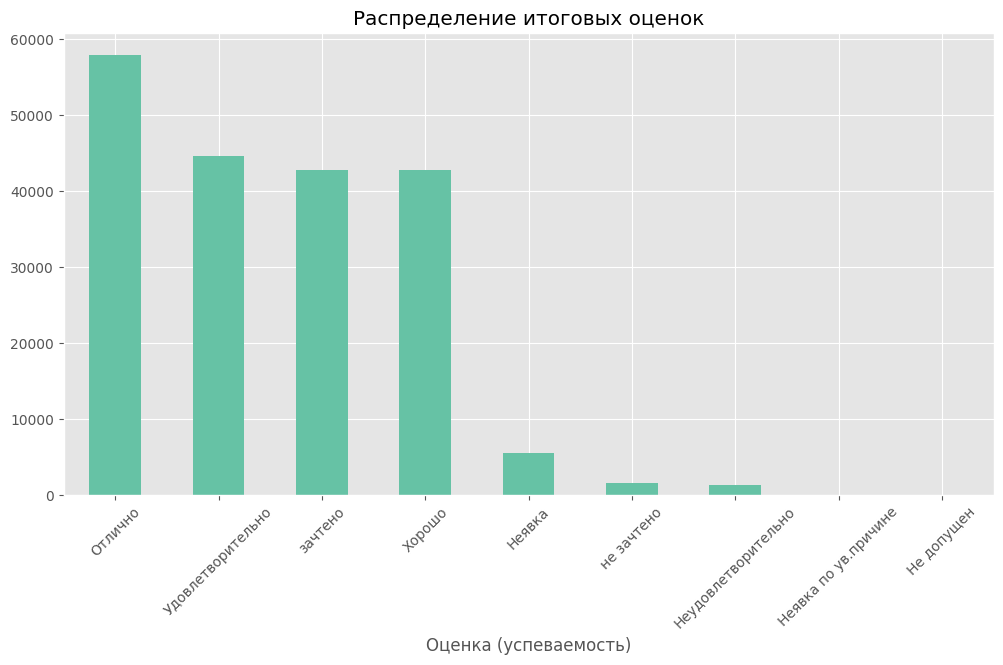

In [12]:
plt.figure(figsize=(12,6))

df["Оценка (успеваемость)"]\
.value_counts()\
.plot.bar()

plt.xticks(rotation=45)

plt.title("Распределение итоговых оценок")

plt.show()

Наиболее распространёнными являются оценки
"Отлично","Удовлетвеорительно" "Хорошо" и "зачтено".

Неудовлетворительные результаты встречаются значительно реже.

8. Распределение студентов по полугодиям

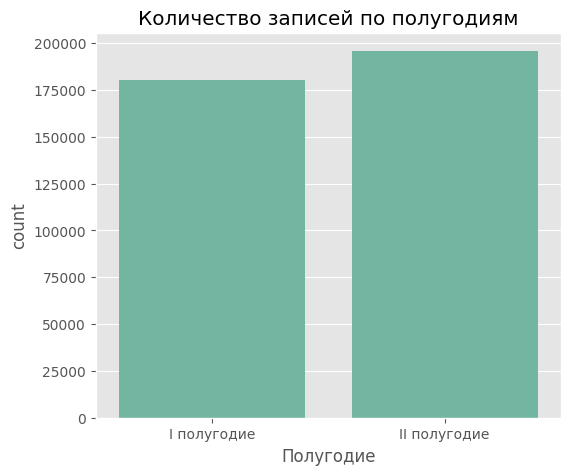

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Полугодие")

plt.title("Количество записей по полугодиям")

plt.show()

Количество наблюдений по обоим полугодиям примерно одинаковое.

9. Самые популярные дисциплины

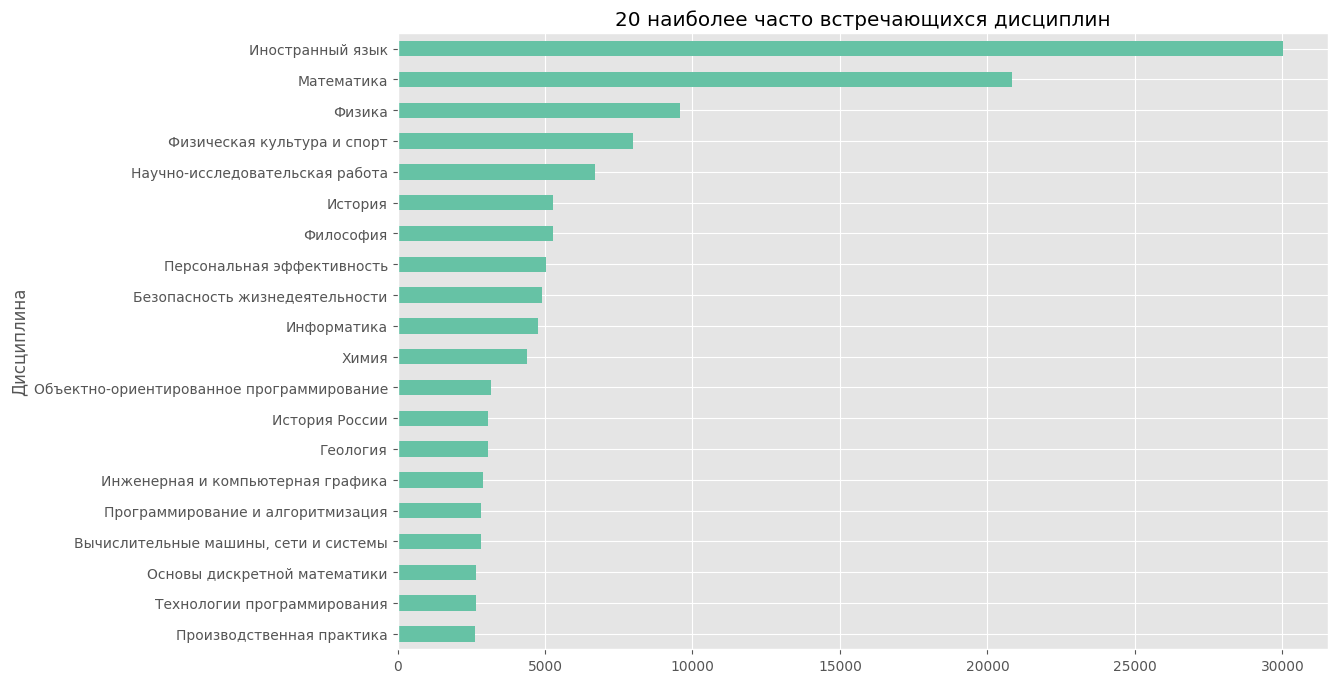

In [14]:
top = df["Дисциплина"].value_counts().head(20)

plt.figure(figsize=(12,8))

top.sort_values().plot.barh()

plt.title("20 наиболее часто встречающихся дисциплин")

plt.show()

10. Какие дисциплины чаще заканчиваются задолженностью

In [15]:
bad_marks = [
    "Неудовлетворительно",
    "Неявка",
    "Неявка по ув. причине",
    "не зачтено",
    "Не допущен"
]

In [16]:
bad = df[
    df["Оценка (успеваемость)"].isin(bad_marks)
]

In [17]:
bad["Дисциплина"]\
.value_counts()\
.head(20)

Дисциплина
Иностранный язык                                                                                        600
Научно-исследовательская работа                                                                         454
Математика                                                                                              206
Физика                                                                                                  169
Курсовая научно-исследовательская работа                                                                151
Производственная практика                                                                               127
Химия                                                                                                   117
Композиция                                                                                              110
Прикладной статистический анализ                                                                         90
Объектно-ориентир

Данные дисциплины требуют дополнительного внимания.

Именно они могут стать хорошими признаками сложности курса.

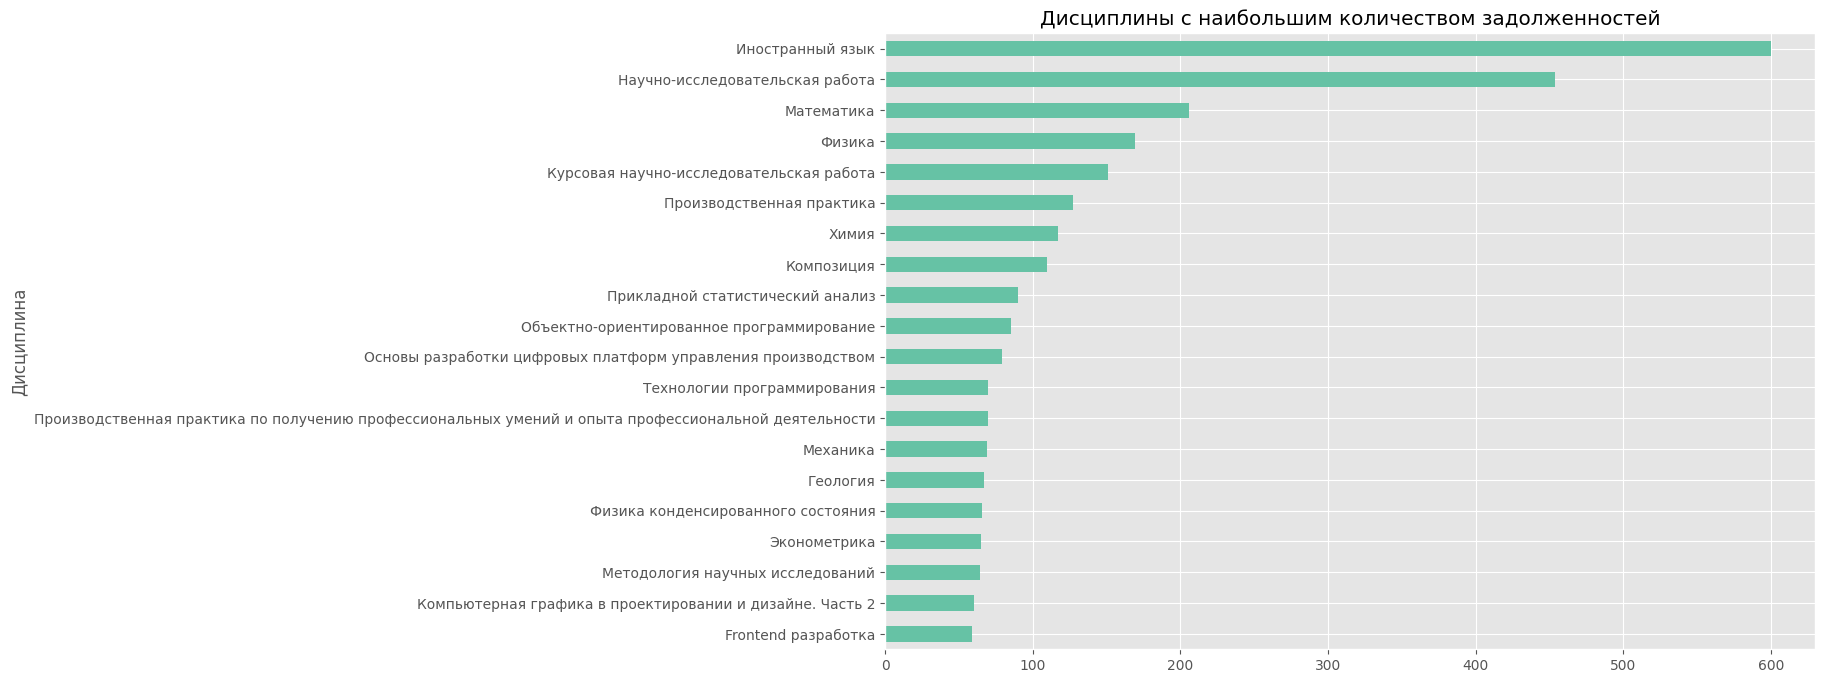

In [18]:
plt.figure(figsize=(12,8))

bad["Дисциплина"]\
.value_counts()\
.head(20)\
.sort_values()\
.plot.barh()

plt.title("Дисциплины с наибольшим количеством задолженностей")

plt.show()

11. Доля задолженностей

In [19]:
df["Задолженность"] = df["Оценка (успеваемость)"].isin(bad_marks)

In [20]:
df["Задолженность"].value_counts(normalize=True)

Задолженность
False    0.977394
True     0.022606
Name: proportion, dtype: float64

Круговая диаграмма задолжностей

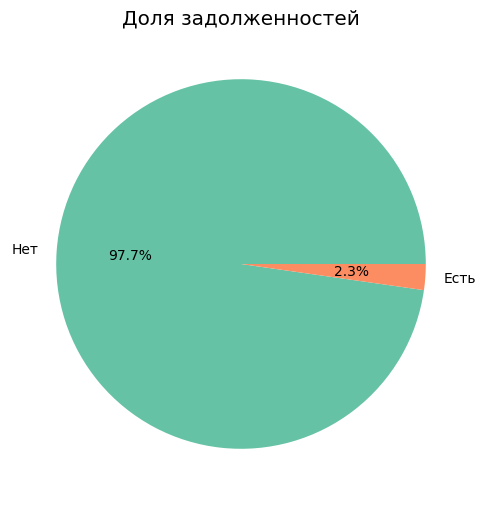

In [21]:
plt.figure(figsize=(6,6))

df["Задолженность"]\
.value_counts()\
.plot.pie(
    autopct="%.1f%%",
    labels=["Нет","Есть"]
)

plt.ylabel("")

plt.title("Доля задолженностей")

plt.show()

12. Какие направления подготовки наиболее рискованные

In [22]:
risk = df.groupby(
    "Специальность/направление"
)["Задолженность"].mean()

In [23]:
risk.sort_values(ascending=False).head(15)

Специальность/направление
Управление в технических системах                             0.137874
Технологические машины и оборудование                         0.070839
Металлургия                                                   0.067370
Нанотехнологии и микросистемная техника                       0.055478
Электроэнергетика и электротехника                            0.041689
Наземные транспортно-технологические средства                 0.041106
Электроника и наноэлектроника                                 0.037349
Менеджмент                                                    0.030612
Горное дело                                                   0.028758
Информатика и вычислительная техника                          0.023754
Экономика                                                     0.023658
Материаловедение и технологии материалов                      0.020786
Информационные системы и технологии                           0.020732
Физические процессы горного или нефтегазового произ

График "Направления с максимальной долей задолженностей"

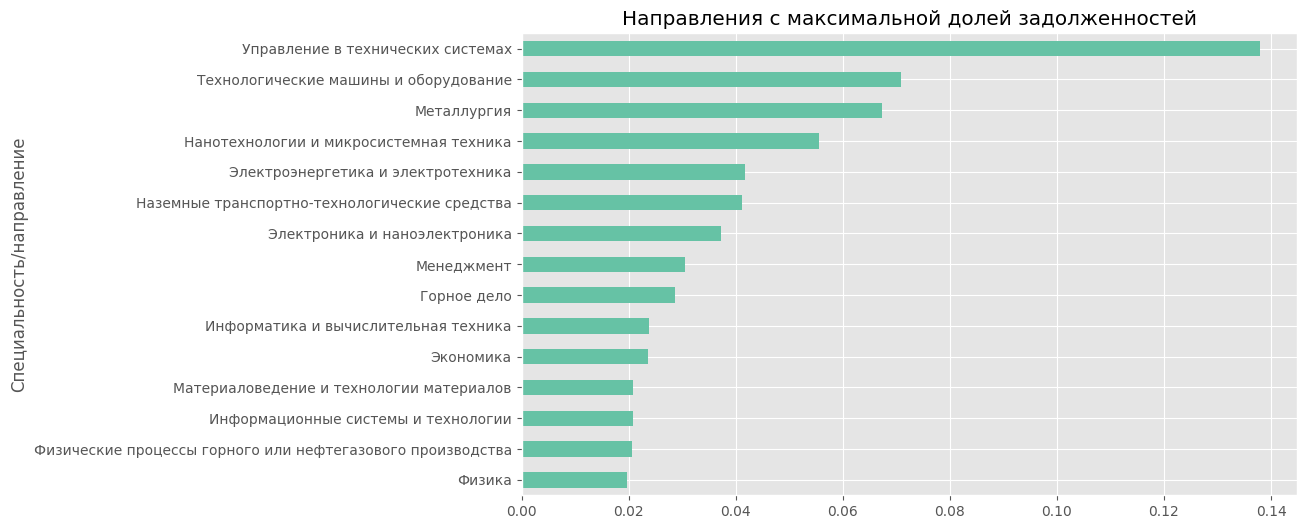

In [24]:
risk.sort_values().tail(15).plot.barh(figsize=(10,6))

plt.title("Направления с максимальной долей задолженностей")

plt.show()

13. Какие группы наиболее проблемные

In [25]:
group_risk = (
    df.groupby("Учебная группа")
      ["Задолженность"]
      .mean()
)

In [26]:
group_risk.sort_values(ascending=False).head(20)

Учебная группа
ММТ-22-9       0.695652
ММТ-22-13      0.512077
МЭН-22-1       0.461538
МТМО-22-3      0.453222
МНТМ-22-2А     0.325581
МНТМ-22-1      0.302326
МИВТ-22-1      0.270142
СГД-21-6з      0.239344
ММТ-22-12      0.223214
МТМО-22-6      0.222222
ММТ-22-2       0.194805
МУТС-22-1      0.176339
МТМО-22-7      0.170807
МПИ-22-5       0.166667
МИСТ-23-1-1    0.143911
ММТ-22-3       0.141956
МЭЭ-22-1       0.131890
МТМО-22-2      0.129237
ММТ-22-11      0.125000
БЭЭ-22-1       0.120841
Name: Задолженность, dtype: float64

14. Сезонность

In [27]:
season = df.groupby("Полугодие")["Задолженность"].mean()

season

Полугодие
I полугодие     0.024796
II полугодие    0.020590
Name: Задолженность, dtype: float64

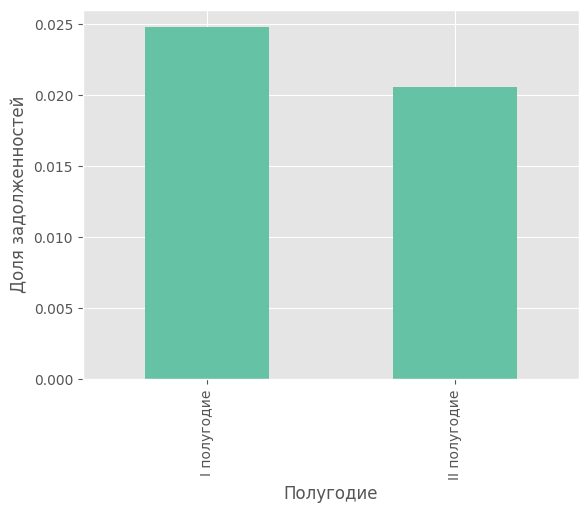

In [28]:
season.plot.bar()

plt.ylabel("Доля задолженностей")

plt.show()

Сравнение полугодий показывает,
существует ли сезонность появления задолженностей.

15. Самые сложные дисциплины

In [29]:
difficulty = (
    df.groupby("Дисциплина")["Задолженность"]
      .mean()
)

In [30]:
difficulty.sort_values(ascending=False).head(20)

Дисциплина
Методология и практика определения размерных характеристик наноматериалов                                               1.000000
Модификация поверхности конструкционных сплавов для создания материалов нового поколени                                 0.833333
Диагностика и экспертиза коррозионных разрушений металлов                                                               0.833333
Современные жаростойкие материалы и системы "металл-покрытие"                                                           0.833333
Современные коррозионностойкие материалы                                                                                0.833333
Анализ данных и планирование эксперимента                                                                               0.777778
Проектирование производственного участка                                                                                0.750000
Защитные покрытия на металлопродукции                                                 

16. Динамика успеваемости студентов

Это уже анализ по студентам.

Сколько студентов имеют задолженности вообще?

In [31]:
student_risk = (
    df.groupby("hash")["Задолженность"]
      .sum()
)

student_risk.describe()

count    9085.000000
mean        0.935608
std         2.644281
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        36.000000
Name: Задолженность, dtype: float64

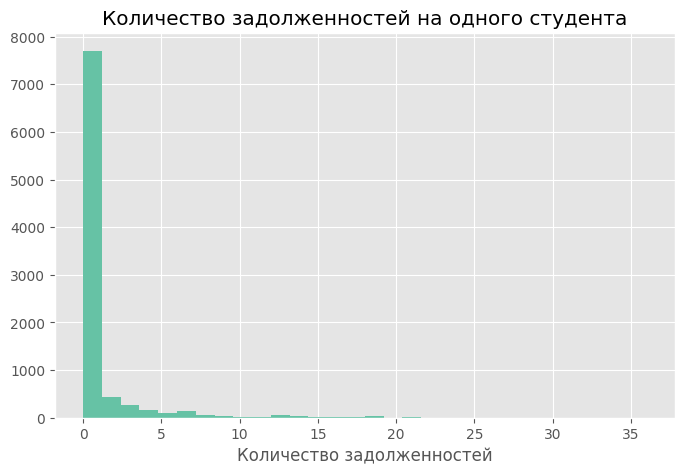

In [32]:
plt.figure(figsize=(8,5))

student_risk.hist(bins=30)

plt.title("Количество задолженностей на одного студента")

plt.xlabel("Количество задолженностей")

plt.show()

17. Топ студентов по количеству задолженностей

In [33]:
top_students = (
    df.groupby("hash")["Задолженность"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_students

hash
519edc243dfd4287af8936c50aa7c302    36
bc581af1a3ba648940a43feec887f818    30
bfb7b9fd8d98f0dcd37425cede0e5171    29
abe9c86700e0cf112bc176d940d1ee60    25
75d84a7083a6524513112bcac0c4eb4b    25
733567b087276c87a245750fd7f23cb2    25
b30187c6062b4806c6d75b3be49d09d3    22
31382845f8cbd8c72e2bfa1dfee9de5b    22
44510fbc393a790601b64d2bdf6a095a    22
b2b80803b06b495627bdb929d6818fb5    21
4b2f1901ed17dfa0157bad27d3391e14    21
4a77e6645456db5dfe2772a28b3d12d0    21
eff8950975b8a57a2b7d66a1eaf4117b    21
4348468f1a38f61c1c17bdd1c9cd0c3a    21
dcbe9df875b3f05c8cbf4afedb4ef79f    20
b2f1ca7a6859cc57fe4e9e3f5b5d07d1    20
a1023ae93098fa20547fe05b1e2fba41    20
ce165b090639717954b33359d1a06303    20
a5a94047ec3342e229e9e4ce2b147a2e    19
d932b0287f424393d2f701e638fab74e    19
Name: Задолженность, dtype: int64

18. Анализ учебных лет

In [34]:
year_risk = (
    df.groupby("Учебный год")["Задолженность"]
      .mean()
)

year_risk

Учебный год
2017 - 2018    0.000000
2018 - 2019    0.000870
2019 - 2020    0.005435
2020 - 2021    0.004181
2021 - 2022    0.006735
2022 - 2023    0.046889
2023 - 2024    0.016140
2024 - 2025    0.000000
2025 - 2026    0.000000
2026 - 2027    0.000000
2027 - 2028    0.000000
Name: Задолженность, dtype: float64

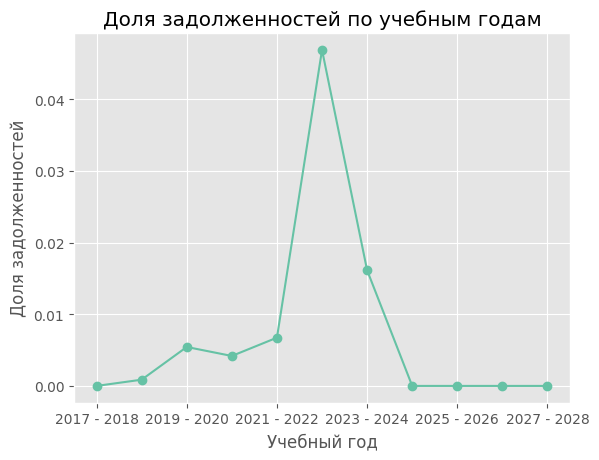

In [35]:
year_risk.plot(marker="o")

plt.ylabel("Доля задолженностей")

plt.title("Доля задолженностей по учебным годам")

plt.show()

19. Матрица "Полугодие × Оценка"

In [36]:
pivot = pd.crosstab(
    df["Полугодие"],
    df["Оценка (успеваемость)"]
)

pivot

Оценка (успеваемость),Не допущен,Неудовлетворительно,Неявка,Неявка по ув.причине,Отлично,Удовлетворительно,Хорошо,зачтено,не зачтено
Полугодие,,,,,,,,,
I полугодие,0,580,2870,5,27475,20909,21094,24131,1018
II полугодие,1,839,2634,4,30388,23668,21667,18681,558


Тепловая карта

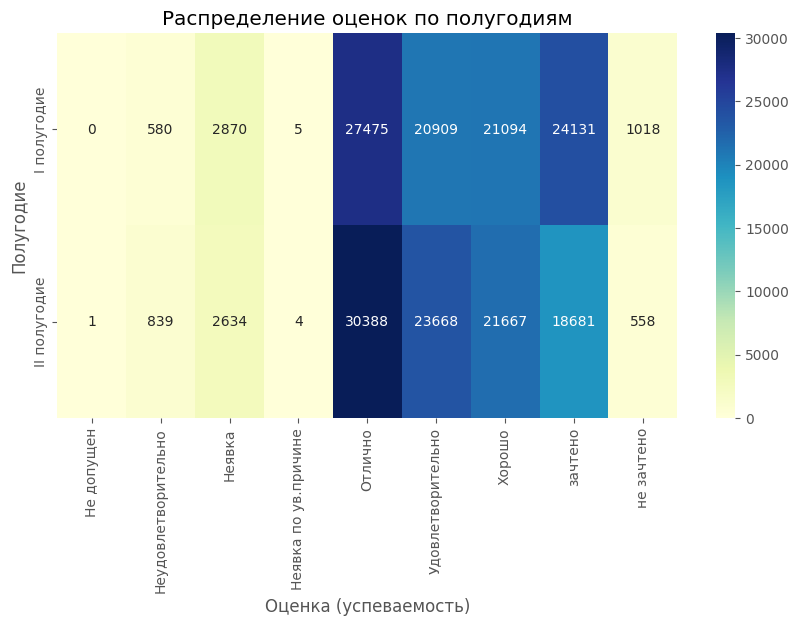

In [37]:
plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Распределение оценок по полугодиям")

plt.show()

20. Самые сложные дисциплины (не по количеству, а по проценту долгов)

In [38]:
difficulty = (
    df.groupby("Дисциплина")
      .agg(
          Всего=("Задолженность","count"),
          Долгов=("Задолженность","sum")
      )
)

difficulty["Доля"] = (
    difficulty["Долгов"] /
    difficulty["Всего"]
)

difficulty.sort_values("Доля", ascending=False).head(20)

,Всего,Долгов,Доля
Дисциплина,,,
Методология и практика определения размерных характеристик наноматериалов,3,3,1.000000
Модификация поверхности конструкционных сплавов для создания материалов нового поколени,6,5,0.833333
Диагностика и экспертиза коррозионных разрушений металлов,6,5,0.833333
"Современные жаростойкие материалы и системы ""металл-покрытие""",6,5,0.833333
Современные коррозионностойкие материалы,6,5,0.833333
Анализ данных и планирование эксперимента,9,7,0.777778
Проектирование производственного участка,8,6,0.750000
Защитные покрытия на металлопродукции,6,4,0.666667
Современные проблемы нанотехнологий,6,4,0.666667


21. Сложность специальностей

In [39]:
faculty = (
    df.groupby("Специальность/направление")
      .agg(
          Всего=("Задолженность","count"),
          Долгов=("Задолженность","sum")
      )
)

faculty["Доля"] = (
    faculty["Долгов"] /
    faculty["Всего"]
)

faculty.sort_values("Доля", ascending=False)

,Всего,Долгов,Доля
Специальность/направление,,,
Управление в технических системах,602,83,0.137874
Технологические машины и оборудование,12719,901,0.070839
Металлургия,16773,1130,0.067370
Нанотехнологии и микросистемная техника,4272,237,0.055478
Электроэнергетика и электротехника,5493,229,0.041689
Наземные транспортно-технологические средства,1411,58,0.041106
Электроника и наноэлектроника,9987,373,0.037349
Менеджмент,21560,660,0.030612
Горное дело,42215,1214,0.028758


22. Признаки для будущей модели

In [40]:
features = pd.DataFrame({

"Признак":[

"Количество дисциплин",

"Количество неудовлетворительных оценок",

"Количество неявок",

"Количество зачетов",

"Доля задолженностей",

"Полугодие",

"Направление подготовки",

"Учебная группа",

"Сложность дисциплины"

],

"Причина":[

"Учебная нагрузка",

"Главный показатель риска",

"Признак проблемной успеваемости",

"Интенсивность обучения",

"Общий уровень риска",

"Проверка сезонности",

"Различия программ",

"Особенности групп",

"Сложность курса"

]

})

features

,Признак,Причина
0,Количество дисциплин,Учебная нагрузка
1,Количество неудовлетворительных оценок,Главный показатель риска
2,Количество неявок,Признак проблемной успеваемости
3,Количество зачетов,Интенсивность обучения
4,Доля задолженностей,Общий уровень риска
5,Полугодие,Проверка сезонности
6,Направление подготовки,Различия программ
7,Учебная группа,Особенности групп
8,Сложность дисциплины,Сложность курса


    23. Основные результаты EDA

1. Датасет содержит более 376 тыс. записей по результатам обучения студентов.

2. Пропуски в оценках обусловлены различными формами контроля и требуют дополнительной проверки на этапе предобработки.

3. Выявлены дисциплины с наибольшей долей задолженностей, которые могут использоваться как признак сложности.

4. Получено распределение задолженностей по направлениям подготовки и учебным группам.

5. Проверено наличие сезонности между I и II полугодием.

6. Подготовлен перечень признаков для Feature Engineering.

24. Feature Engineering Preview

In [41]:
student_features = (
    df.groupby([
        "hash",
        "Учебный год",
        "Полугодие"
    ])
    .agg(

        disciplines=("Дисциплина","count"),

        debts=("Задолженность","sum"),

        excellent=("Оценка (успеваемость)",lambda x:(x=="Отлично").sum()),

        good=("Оценка (успеваемость)",lambda x:(x=="Хорошо").sum()),

        satisfactory=("Оценка (успеваемость)",lambda x:(x=="Удовлетворительно").sum()),

        bad=("Оценка (успеваемость)",lambda x:(x=="Неудовлетворительно").sum()),

        absent=("Оценка (успеваемость)",lambda x:(x=="Неявка").sum()),

        passed=("Оценка (успеваемость)",lambda x:(x=="зачтено").sum())

    )
)

student_features.head()

disciplines  debts  \
hash                             Учебный год Полугодие                          
000006af6e40c8234a5af27896b7bba5 2020 - 2021 I полугодие             7      0   
                                             II полугодие            9      0   
                                 2021 - 2022 I полугодие             9      0   
                                             II полугодие            9      0   
                                 2022 - 2023 I полугодие             9      0   

                                                           excellent  good  \
hash                             Учебный год Полугодие                       
000006af6e40c8234a5af27896b7bba5 2020 - 2021 I полугодие           0     0   
                                             II полугодие          0     1   
                                 2021 - 2022 I полугодие           3     1   
                                             II полугодие          1     0   
                                 2022 - 2023 I полугодие           0     1   

                                                           satisfactory  bad  \
hash                             Учебный год Полугодие                         
000006af6e40c8234a5af27896b7bba5 2020 - 2021 I полугодие              4    0   
                                             II полугодие             5    0   
                                 2021 - 2022 I полугодие              3    0   
                                             II полугодие             6    0   
                                 2022 - 2023 I полугодие              4    0   

                                                           absent  passed  
hash                             Учебный год Полугодие                     
000006af6e40c8234a5af27896b7bba5 2020 - 2021 I полугодие        0       3  
                                             II полугодие       0       3  
                                 2021 - 2022 I полугодие        0       2  
                                             II полугодие       0       2  
                                 2022 - 2023 I полугодие        0       4

    25. Рекомендации по Feature Engineering

1. Использовать количество дисциплин за семестр.

2. Использовать количество задолженностей.

3. Использовать количество неудовлетворительных оценок.

4. Использовать количество неявок.

5. Использовать долю успешно закрытых дисциплин.

6. Использовать учебный год и полугодие как временные признаки.

7. Рассчитать сложность дисциплины как историческую долю задолженностей.

8. Рассчитать среднюю успеваемость группы.

9. Добавить тренд изменения успеваемости студента между семестрами.

10. Построить целевую переменную как количество задолженностей в следующем семестре.